In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from modules.pf_training import get_train_data_pf
from main import rotated_split
from modules.utils.validation_utils import parse_bamboo_csv
RANDOM_STATE = 42

In [2]:
def load_bamboo_data_filters(bamboo_output_file):
    best_configs_df = parse_bamboo_csv(bamboo_output_file)
    data = []
    for _, row in best_configs_df.iterrows():
        # filter len is the number of non zero elem
        filter_len = sum([1 for val in row["best_filter"] if val != 0])
        # filter_first_nonzero is the index of the first non zero elem
        filter_first_nonzero = next((i for i, val in enumerate(row["best_filter"]) if val != 0), None)
        data.append((filter_len, filter_first_nonzero))
    return data

def plot_bamboo_pf_filters(u_filtering, fingerprint_threshold, data_bamboo, indexes):
    colors = plt.cm.tab10.colors  # Use seaborn tab10 color palette
    # Set figure size and high DPI for print quality
    plt.figure(figsize=(25, 9), dpi=300)

    # Plot the main line with large markers and thick lines for visibility
    plt.plot(
        u_filtering[:650],
        marker="",
        markersize=12,  # Larger marker size
        linestyle="-",
        linewidth=3,  # Thicker line
        color=colors[3],  # Use the first color from sns tab10 palette
        label="Filtered Suitability Vector",
        alpha=0.8,
    )

    # Add the fingerprint threshold line with a thicker line
    plt.axhline(
        y=fingerprint_threshold,
        color=colors[9],  # Use the second color from sns tab10 palette
        linestyle="--",
        linewidth=3,
        label="Fingerprint Threshold",
    )

    # Shade background for intervals P to P + L with more distinct colors and opacity
    for l, p in data_bamboo:
        plt.axvspan(
            p,
            p + l,
            color=colors[2],  # Use the third color from sns tab10 palette
            alpha=0.3,  # Less transparency for visibility
            ymax=fingerprint_threshold*0.985,
        )

    # Shade background for each index in indexes
    for index in indexes:
        plt.axvspan(int(index), int(index) + 1, color=colors[0], alpha=0.3, ymin=fingerprint_threshold*0.985)

    # Increase font sizes for title, labels, and grid
    plt.xlabel("Bit Index", fontsize=26)
    plt.ylabel("Suitability", fontsize=26)
    plt.grid(True, linestyle="--", alpha=0.6)

    # Increase font size for axis ticks
    plt.tick_params(axis="both", which="major", labelsize=22)

    # Define legend with even larger font sizes and clearer labels
    bamboo_patch = Patch(color=colors[2], alpha=0.5, label="BAMBOO Intervals")
    pf_patch = Patch(color=colors[0], alpha=0.5, label="PF Intervals")
    filtered_line = Line2D(
        [],
        [],
        color=colors[3],
        marker="",
        linestyle="-",
        markersize=12,
        linewidth=3,
        label="Filtered Suitability Vector",
    )
    threshold_line = Line2D(
        [], [], color=colors[9], linestyle="--", linewidth=3, label="Fingerprint Threshold"
    )
    # Add legend with large font size and position it
    plt.legend(handles=[bamboo_patch, pf_patch, filtered_line, threshold_line],fontsize=22,loc="upper right")
    plt.tight_layout()
    plt.show()


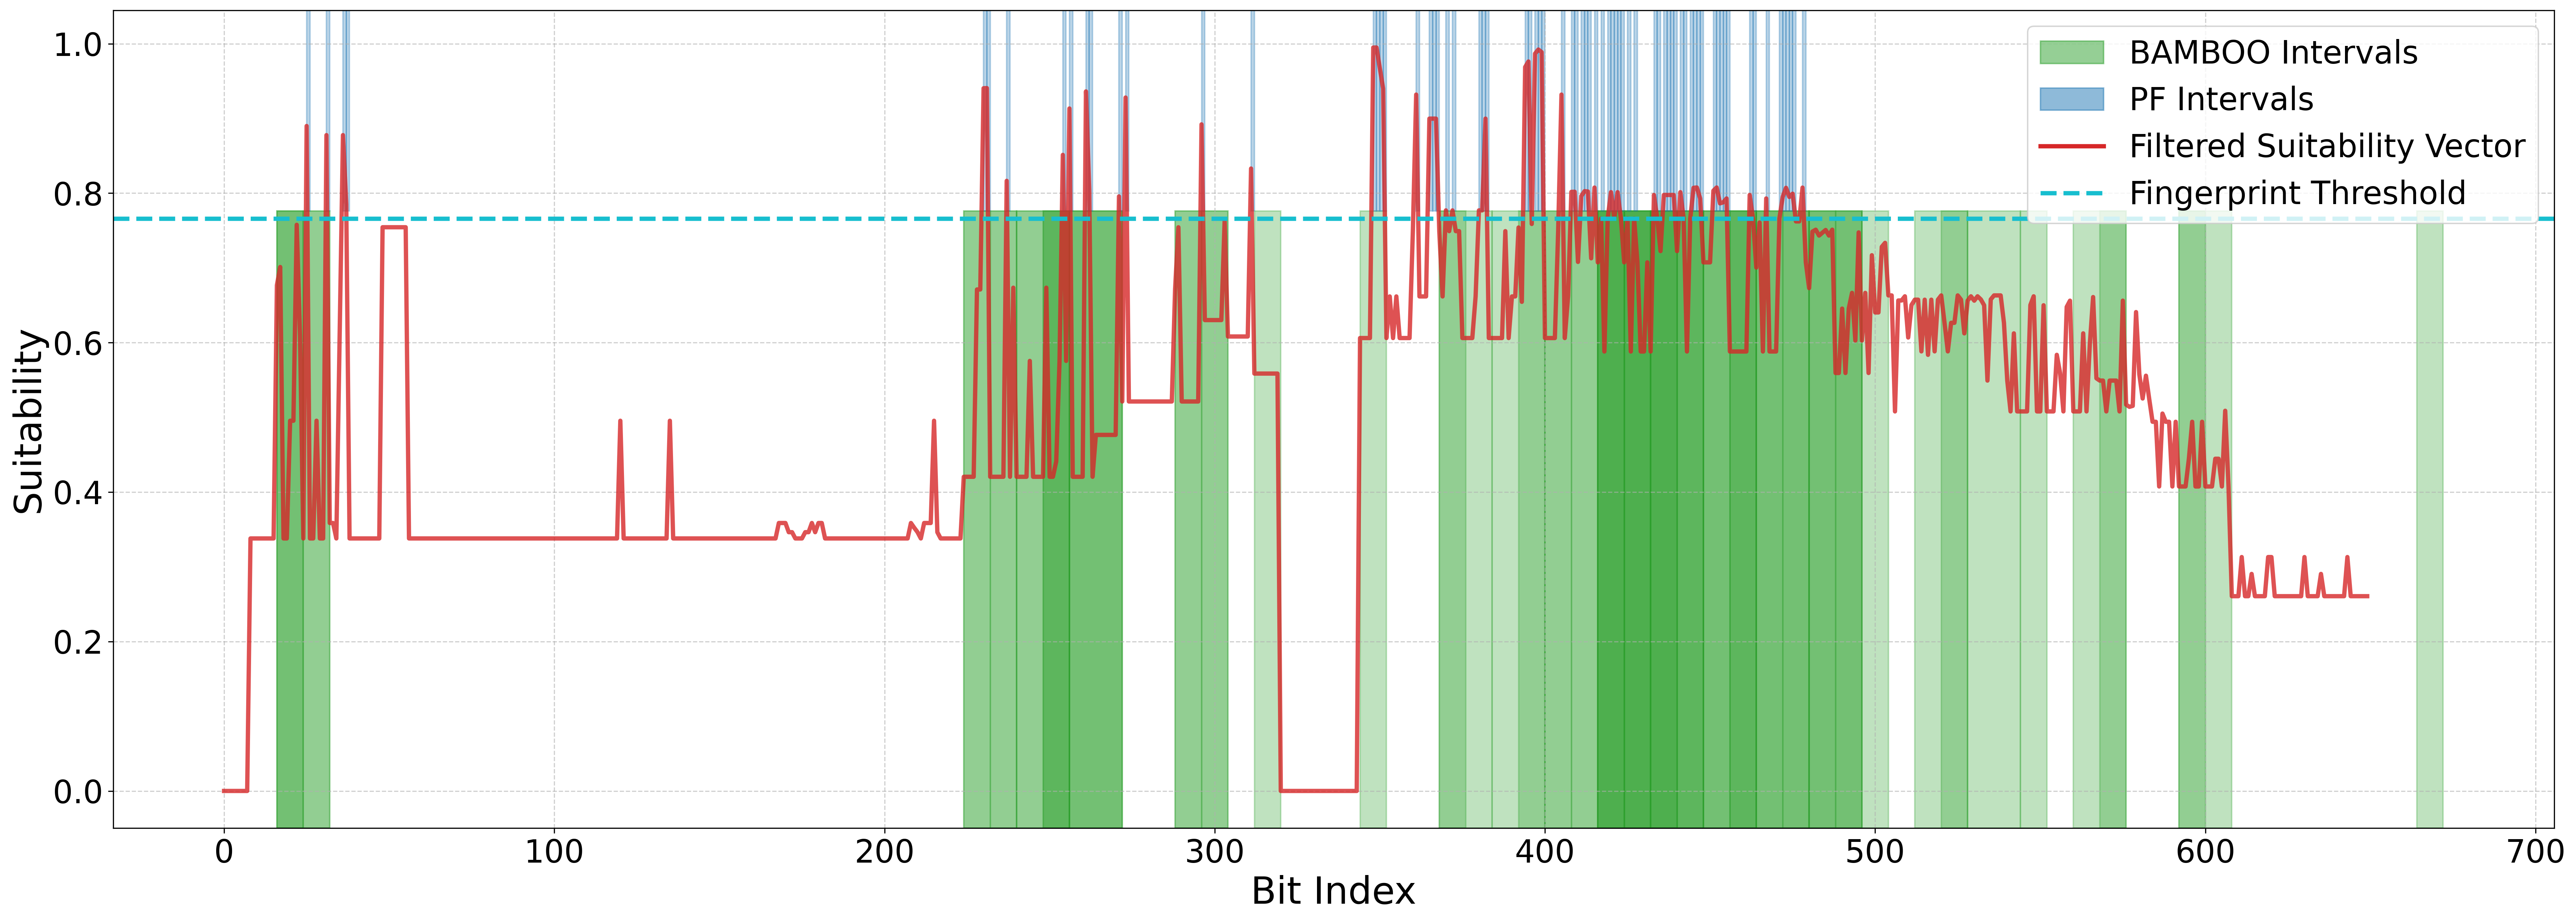

In [10]:
cycle = 9
out_folder = f"C:/Users/fabio/Ricerca/Codice/2026_Bamboo_Journal/well_structured/results/"
out_dir = out_folder + f"cycle_{cycle}/"
data_folder = "C:/Users/fabio/Ricerca/Codice/2026_Bamboo_Journal/well_structured/data/interim/"

# load bin file
bin_U_filename = "binary_U_balanced.csv"
bin_U_df = pd.read_csv(data_folder + bin_U_filename, dtype=str)
if "label" not in bin_U_df.columns:
        bin_U_df["label"] = bin_U_df.index.astype(str)

# obtain train labels for cycle {cycle}
unique_labels = bin_U_df["label"].unique().tolist() 
unique_labels.sort()
rng = np.random.default_rng(RANDOM_STATE)
rng.shuffle(unique_labels)
train_labels, val_labels, test_labels = rotated_split(unique_labels, cycle)
# filter bin_U_df to keep only rows with labels in train_labels
pf_train_df = bin_U_df[bin_U_df["label"].isin(train_labels)].copy()

# load bamboo filter data
bamboo_output_file = out_dir + f"bamboo_output.csv"
data_bamboo = load_bamboo_data_filters(bamboo_output_file)

fingerprint_threshold, u_filtering, indexes = get_train_data_pf(pf_train_df, num_bits=64)
plot_bamboo_pf_filters(u_filtering, fingerprint_threshold, data_bamboo, indexes)